# Model Evaluation Utilities Demo - German Credit Dataset (Real Target)



## Setup and Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from fair_credit.models.metrics import ModelMetrics, ModelEvaluator
from fair_credit.models import LogisticRegressionModel, XGBoostModel

np.random.seed(42)

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Load and Explore German Credit Dataset

In [3]:
df = pd.read_csv('../data/german_credit_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print(f"\nFirst 5 rows:")
display(df.head())

print(f"\nDataset info:")
print(f"- Total samples: {len(df)}")
print(f"- Features: {len(df.columns) - 1}")
print(f"- Missing values: {df.isnull().sum().sum()}")

if 'Risk' in df.columns:
    print(f"\nTarget Variable Analysis:")
    print(f"Target values: {df['Risk'].unique()}")
    print(f"\nTarget distribution:")
    target_counts = df['Risk'].value_counts()
    target_pct = df['Risk'].value_counts(normalize=True)
    for value in target_counts.index:
        print(f"  {value}: {target_counts[value]} ({target_pct[value]:.1%})")
else:
    print("No 'Risk' column found in dataset")

print(f"\nData types:")
print(df.dtypes)

Dataset shape: (1000, 11)

Columns: ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']

First 5 rows:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad



Dataset info:
- Total samples: 1000
- Features: 9
- Missing values: 577

Target Variable Analysis:
Target values: ['good' 'bad']

Target distribution:
  good: 700 (70.0%)
  bad: 300 (30.0%)

Data types:
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object


## 2. Data Preprocessing and Feature Engineering

In [4]:
data = df.copy()

print("Handling missing values...")
print(f"Missing values before handling:")
missing_before = data.isnull().sum()
print(missing_before[missing_before > 0])

data['Saving accounts'] = data['Saving accounts'].fillna('none')
data['Checking account'] = data['Checking account'].fillna('none')

print(f"\nMissing values after handling: {data.isnull().sum().sum()}")

print("\nProcessing target variable...")
if 'Risk' in data.columns:
    target_mapping = {'good': 0, 'bad': 1}
    data['Risk_Binary'] = data['Risk'].map(target_mapping)
    
    print(f"Target mapping: {target_mapping}")
    print(f"Binary target distribution:")
    print(f"  Good credit (0): {(data['Risk_Binary'] == 0).sum()} ({(data['Risk_Binary'] == 0).mean():.1%})")
    print(f"  Bad credit (1): {(data['Risk_Binary'] == 1).sum()} ({(data['Risk_Binary'] == 1).mean():.1%})")
    
    target_column = 'Risk_Binary'
else:
    print("No Risk column found - cannot proceed with modeling")
    target_column = None

print(f"\nProcessed dataset shape: {data.shape}")
display(data.head())

Handling missing values...
Missing values before handling:
Saving accounts     183
Checking account    394
dtype: int64

Missing values after handling: 0

Processing target variable...
Target mapping: {'good': 0, 'bad': 1}
Binary target distribution:
  Good credit (0): 700 (70.0%)
  Bad credit (1): 300 (30.0%)

Processed dataset shape: (1000, 11)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Risk_Binary
0,67,male,2,own,none,little,1169,6,radio/TV,good,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,1
2,49,male,1,own,little,none,2096,12,education,good,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,0
4,53,male,2,free,little,little,4870,24,car,bad,1


## 3. Feature Preparation for Machine Learning

Let's prepare the features for machine learning models by encoding categorical variables.

In [5]:
if target_column is not None:
    feature_columns = [col for col in data.columns if col not in ['Risk', 'Risk_Binary']]
    X = data[feature_columns].copy()
    y = data[target_column].copy()

    print(f"Features ({len(feature_columns)}): {feature_columns}")
    print(f"Target: {target_column}")

    categorical_columns = X.select_dtypes(include=['object']).columns
    print(f"\nCategorical columns to encode ({len(categorical_columns)}): {categorical_columns.tolist()}")

    label_encoders = {}
    for col in categorical_columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le
        print(f"  Encoded {col}: {le.classes_}")

    feature_names = X.columns.tolist()
    print(f"\nFinal feature names ({len(feature_names)}): {feature_names}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.3, 
        random_state=42, 
        stratify=y
    )

    print(f"\nData split:")
    print(f"- Training set: {X_train.shape[0]} samples")
    print(f"- Test set: {X_test.shape[0]} samples")
    print(f"- Training default rate: {y_train.mean():.2%}")
    print(f"- Test default rate: {y_test.mean():.2%}")

    print(f"\nFeature statistics:")
    display(X_train.describe())
else:
    print("Cannot proceed without target variable")

Features (9): ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']
Target: Risk_Binary

Categorical columns to encode (5): ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
  Encoded Sex: ['female' 'male']
  Encoded Housing: ['free' 'own' 'rent']
  Encoded Saving accounts: ['little' 'moderate' 'none' 'quite rich' 'rich']
  Encoded Checking account: ['little' 'moderate' 'none' 'rich']
  Encoded Purpose: ['business' 'car' 'domestic appliances' 'education' 'furniture/equipment'
 'radio/TV' 'repairs' 'vacation/others']

Final feature names (9): ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Data split:
- Training set: 700 samples
- Test set: 300 samples
- Training default rate: 30.00%
- Test default rate: 30.00%

Feature statistics:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,35.468571,0.701429,1.907143,1.068571,0.857143,1.245714,3200.872857,20.768571,2.798571
std,10.954080,0.457959,0.633997,0.527781,1.210182,0.927822,2674.942042,11.962777,1.965583
min,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,338.000000,4.000000,0.000000
25%,27.000000,0.000000,2.000000,1.000000,0.000000,0.000000,1360.750000,12.000000,1.000000
50%,33.000000,1.000000,2.000000,1.000000,0.000000,1.000000,2319.500000,18.000000,3.000000
75%,41.250000,1.000000,2.000000,1.000000,2.000000,2.000000,3974.500000,24.000000,5.000000
max,75.000000,1.000000,3.000000,2.000000,4.000000,3.000000,15945.000000,60.000000,7.000000


## 4. Train Multiple Models

In [6]:
if target_column is not None:
    models = {}
    predictions = {}

    print("Training models on real German credit data...")

    print("\n1. Training Custom Logistic Regression model...")
    try:
        lr_model = LogisticRegressionModel(
            tune_hyperparameters=False,  
            calibrate=True,
            random_state=42
        )
        lr_model.fit(X_train, y_train)
        models['Custom Logistic Regression'] = lr_model
        predictions['Custom Logistic Regression'] = {
            'y_true': y_test.values,
            'y_proba': lr_model.predict_proba(X_test)[:, 1],
            'y_pred': lr_model.predict(X_test)
        }
        print("Custom Logistic Regression trained successfully")
    except Exception as e:
        print(f"Custom Logistic Regression failed: {e}")

    print("\n2. Training Custom XGBoost model...")
    try:
        xgb_model = XGBoostModel(
            tune_hyperparameters=False,
            calibrate=True,
            n_estimators=100,
            random_state=42
        )
        xgb_model.fit(X_train, y_train)
        models['Custom XGBoost'] = xgb_model
        predictions['Custom XGBoost'] = {
            'y_true': y_test.values,
            'y_proba': xgb_model.predict_proba(X_test)[:, 1],
            'y_pred': xgb_model.predict(X_test)
        }
        print("Custom XGBoost trained successfully")
    except Exception as e:
        print(f"Custom XGBoost failed: {e}")

    print("\n3. Training Random Forest model...")
    try:
        rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_model.fit(X_train, y_train)
        models['Random Forest'] = rf_model
        predictions['Random Forest'] = {
            'y_true': y_test.values,
            'y_proba': rf_model.predict_proba(X_test)[:, 1],
            'y_pred': rf_model.predict(X_test)
        }
        print("Random Forest trained successfully")
    except Exception as e:
        print(f"Random Forest failed: {e}")

    print("\n4. Training Baseline Logistic Regression...")
    try:
        baseline_lr = LogisticRegression(random_state=42, max_iter=1000)
        baseline_lr.fit(X_train, y_train)
        models['Baseline LR'] = baseline_lr
        predictions['Baseline LR'] = {
            'y_true': y_test.values,
            'y_proba': baseline_lr.predict_proba(X_test)[:, 1],
            'y_pred': baseline_lr.predict(X_test)
        }
        print("Baseline Logistic Regression trained successfully")
    except Exception as e:
        print(f"Baseline Logistic Regression failed: {e}")

    print(f"Model training complete! Trained {len(models)} models successfully.")
    print(f"Available models: {list(models.keys())}")
else:
    print("Cannot train models without target variable")

Training models on real German credit data...

1. Training Custom Logistic Regression model...
Custom Logistic Regression trained successfully

2. Training Custom XGBoost model...
Custom XGBoost trained successfully

3. Training Random Forest model...
Random Forest trained successfully

4. Training Baseline Logistic Regression...
Baseline Logistic Regression trained successfully
Model training complete! Trained 4 models successfully.
Available models: ['Custom Logistic Regression', 'Custom XGBoost', 'Random Forest', 'Baseline LR']


## 5. Comprehensive Model Evaluation

In [7]:
if target_column is not None and len(predictions) > 0:
    evaluator = ModelEvaluator(random_state=42)

    model_metrics = {}

    print("COMPREHENSIVE MODEL EVALUATION")
    print("=" * 60)

    for model_name, pred_data in predictions.items():
        print(f"\nEvaluating {model_name}:")
        print("-" * 50)
        
        try:
            metrics = evaluator.compute_metrics(
                y_true=pred_data['y_true'],
                y_proba=pred_data['y_proba'],
                y_pred=pred_data['y_pred']
            )
            
            model_metrics[model_name] = metrics
            
            print(f"Discriminative Performance:")
            print(f"AUC: {metrics.auc:.4f}")
            print(f"AUPRC: {metrics.auprc:.4f}")
            
            print(f"Classification Performance:")
            print(f"Accuracy: {metrics.accuracy:.4f}")
            print(f"F1 Score: {metrics.f1_score:.4f}")
            print(f"Precision: {metrics.precision:.4f}")
            print(f"Recall: {metrics.recall:.4f}")
            print(f"Specificity: {metrics.specificity:.4f}")
            
            print(f"Probabilistic Performance:")
            print(f"Brier Score: {metrics.brier_score:.4f}")
            print(f"Log Loss: {metrics.log_loss:.4f}")
            
            if metrics.calibration_slope is not None:
                print(f"\nCalibration Assessment:")
                print(f"Calibration Slope: {metrics.calibration_slope:.4f}")
                print(f"Calibration Intercept: {metrics.calibration_intercept:.4f}")
                
                if abs(metrics.calibration_slope - 1.0) < 0.1:
                    print(f"Well-calibrated (slope ≈ 1.0)")
                elif metrics.calibration_slope < 1.0:
                    print(f"Overconfident (slope < 1.0)")
                else:
                    print(f"Underconfident (slope > 1.0)")
                
        except Exception as e:
            print(f"Error evaluating {model_name}: {e}")

    print(f"Evaluation complete for {len(model_metrics)} models!")
else:
    print("No models available for evaluation")

🔍 COMPREHENSIVE MODEL EVALUATION

📊 Evaluating Custom Logistic Regression:
--------------------------------------------------
Discriminative Performance:
   AUC: 0.7721
   AUPRC: 0.6246
Classification Performance:
   Accuracy: 0.7300
   F1 Score: 0.4255
   Precision: 0.5882
   Recall: 0.3333
   Specificity: 0.9000
Probabilistic Performance:
   Brier Score: 0.1686
   Log Loss: 0.5115

🎯 Calibration Assessment:
   Calibration Slope: 1.2874
   Calibration Intercept: 0.1465
Underconfident (slope > 1.0)

📊 Evaluating Custom XGBoost:
--------------------------------------------------
Discriminative Performance:
   AUC: 0.7657
   AUPRC: 0.6114
Classification Performance:
   Accuracy: 0.7367
   F1 Score: 0.3680
   Precision: 0.6571
   Recall: 0.2556
   Specificity: 0.9429
Probabilistic Performance:
   Brier Score: 0.1761
   Log Loss: 0.5327

🎯 Calibration Assessment:
   Calibration Slope: 1.6323
   Calibration Intercept: 0.5263
Underconfident (slope > 1.0)

📊 Evaluating Random Forest:
--------

## 6. Model Comparison Visualization

Creating model comparison visualization...


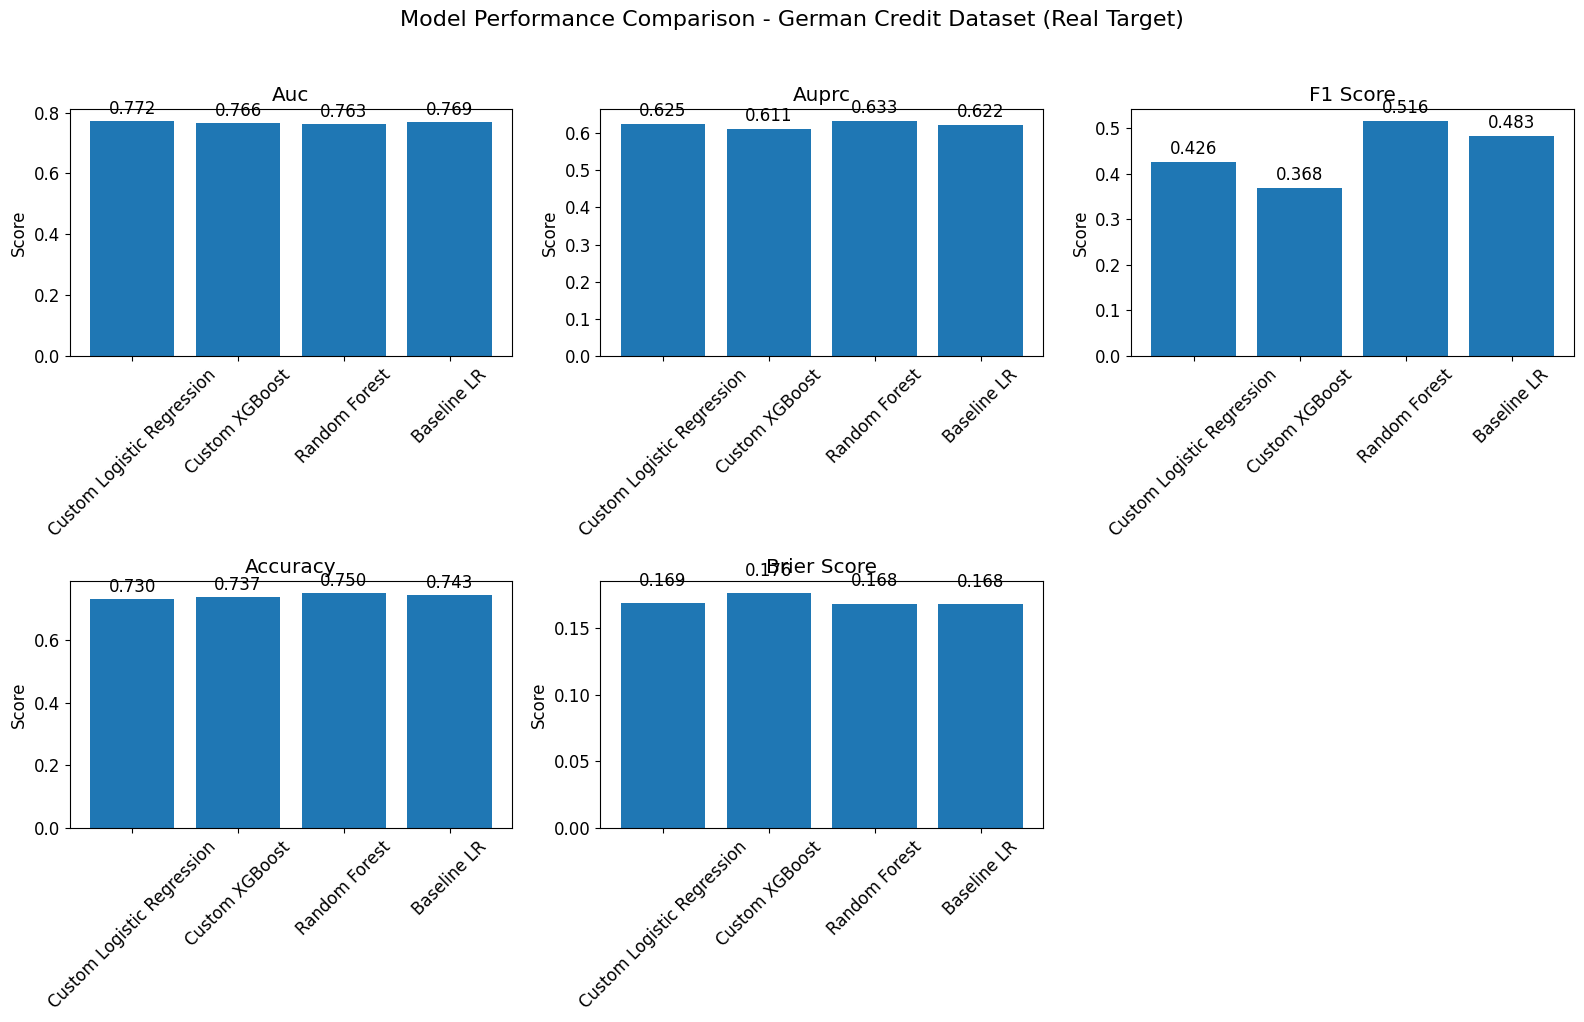

Model comparison visualization complete!


In [8]:
if len(predictions) > 0:
    comparison_data = {}
    for model_name, pred_data in predictions.items():
        comparison_data[model_name] = {
            'y_true': pred_data['y_true'],
            'y_proba': pred_data['y_proba']
        }

    try:
        print("Creating model comparison visualization...")
        
        fig = evaluator.compare_models(
            model_results=comparison_data,
            metrics_to_plot=['auc', 'auprc', 'f1_score', 'accuracy', 'brier_score'],
            figsize=(16, 10)
        )

        plt.suptitle('Model Performance Comparison - German Credit Dataset (Real Target)', 
                    fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

        print("Model comparison visualization complete!")
        
    except Exception as e:
        print(f"Error in model comparison: {e}")
else:
    print("No models available for comparison")

## 7. Detailed Evaluation Plots for Best Model

BEST MODEL ANALYSIS
Best model: Custom Logistic Regression
AUC: 0.7721
F1 Score: 0.4255
Accuracy: 0.7300

Generating detailed evaluation plots...

1. ROC Curve Analysis


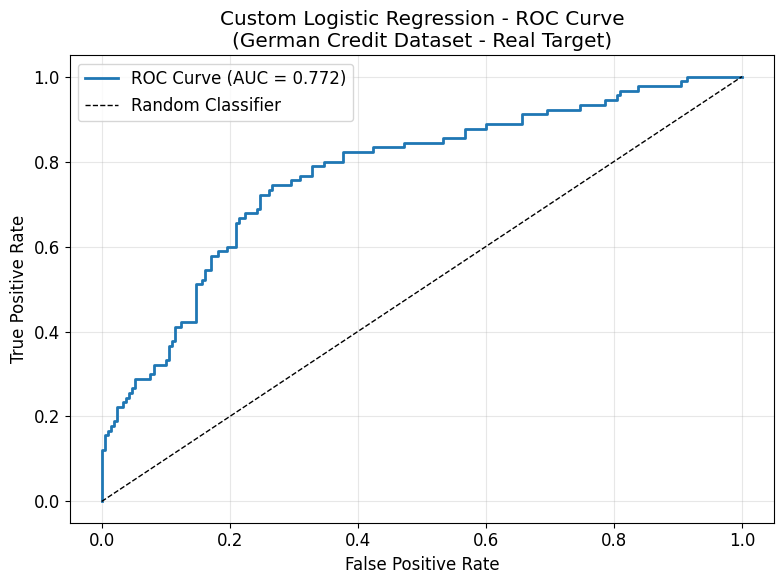


2. Precision-Recall Curve Analysis


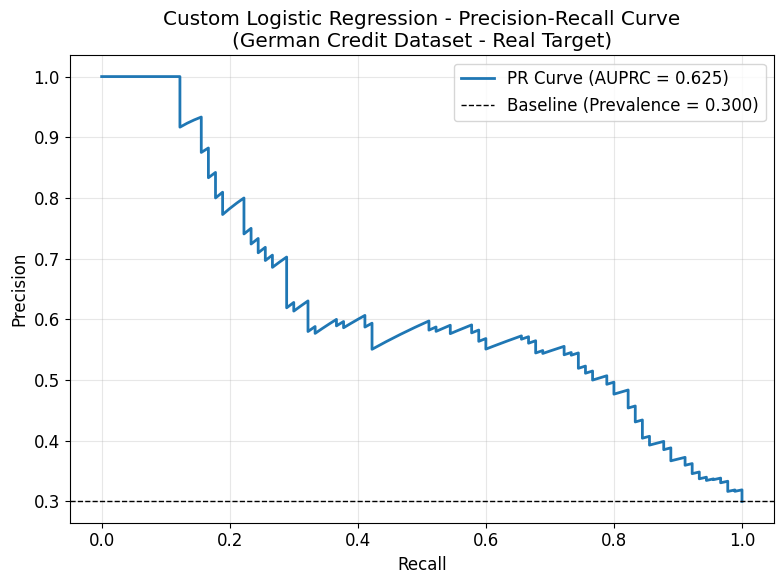


3. Calibration Analysis


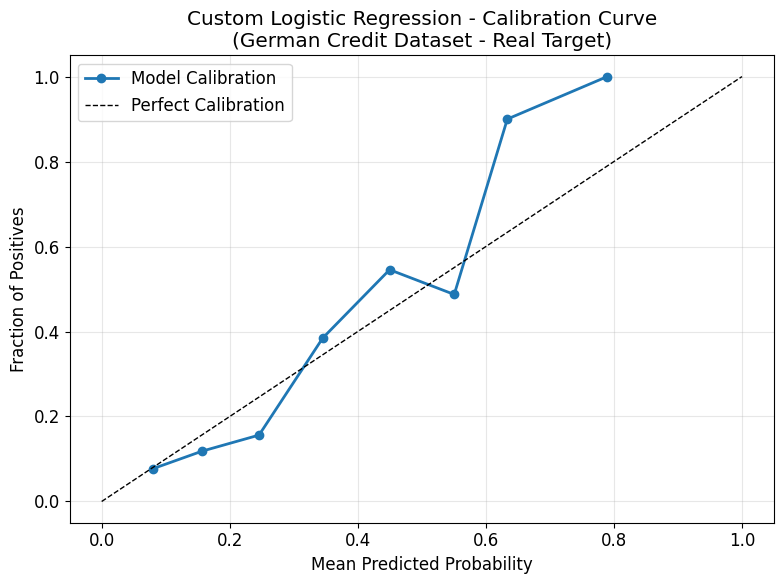


4. Confusion Matrix Analysis


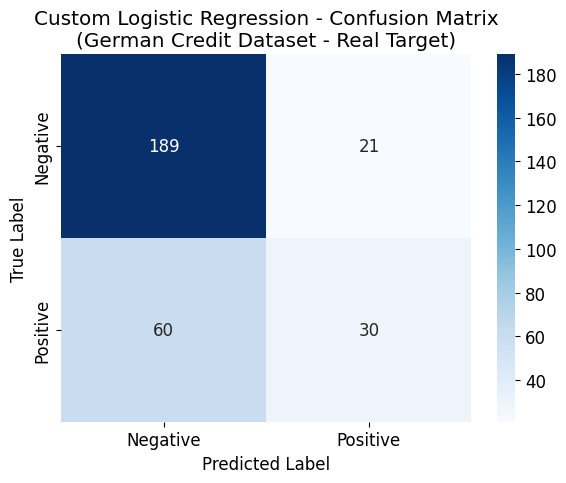

All detailed evaluation plots generated successfully!


In [9]:
if len(model_metrics) > 0:
    best_model_name = max(model_metrics.keys(), key=lambda x: model_metrics[x].auc)
    best_predictions = predictions[best_model_name]
    best_metrics = model_metrics[best_model_name]

    print(f"BEST MODEL ANALYSIS")
    print("=" * 50)
    print(f"Best model: {best_model_name}")
    print(f"AUC: {best_metrics.auc:.4f}")
    print(f"F1 Score: {best_metrics.f1_score:.4f}")
    print(f"Accuracy: {best_metrics.accuracy:.4f}")
    
    print("\nGenerating detailed evaluation plots...")

    try:
        print("\n1. ROC Curve Analysis")
        fig_roc = evaluator.plot_roc_curve(
            y_true=best_predictions['y_true'],
            y_proba=best_predictions['y_proba'],
            title=f"{best_model_name} - ROC Curve\n(German Credit Dataset - Real Target)"
        )
        plt.show()

        print("\n2. Precision-Recall Curve Analysis")
        fig_pr = evaluator.plot_precision_recall_curve(
            y_true=best_predictions['y_true'],
            y_proba=best_predictions['y_proba'],
            title=f"{best_model_name} - Precision-Recall Curve\n(German Credit Dataset - Real Target)"
        )
        plt.show()

        print("\n3. Calibration Analysis")
        fig_cal = evaluator.plot_calibration_curve(
            y_true=best_predictions['y_true'],
            y_proba=best_predictions['y_proba'],
            title=f"{best_model_name} - Calibration Curve\n(German Credit Dataset - Real Target)"
        )
        plt.show()

        print("\n4. Confusion Matrix Analysis")
        fig_cm = evaluator.plot_confusion_matrix(
            y_true=best_predictions['y_true'],
            y_pred=best_predictions['y_pred'],
            title=f"{best_model_name} - Confusion Matrix\n(German Credit Dataset - Real Target)"
        )
        plt.show()

        print("All detailed evaluation plots generated successfully!")
        
    except Exception as e:
        print(f"Error generating detailed plots: {e}")
else:
    print("No models available for detailed evaluation")

## 8. Threshold Analysis for Optimal Decision Making

THRESHOLD OPTIMIZATION ANALYSIS


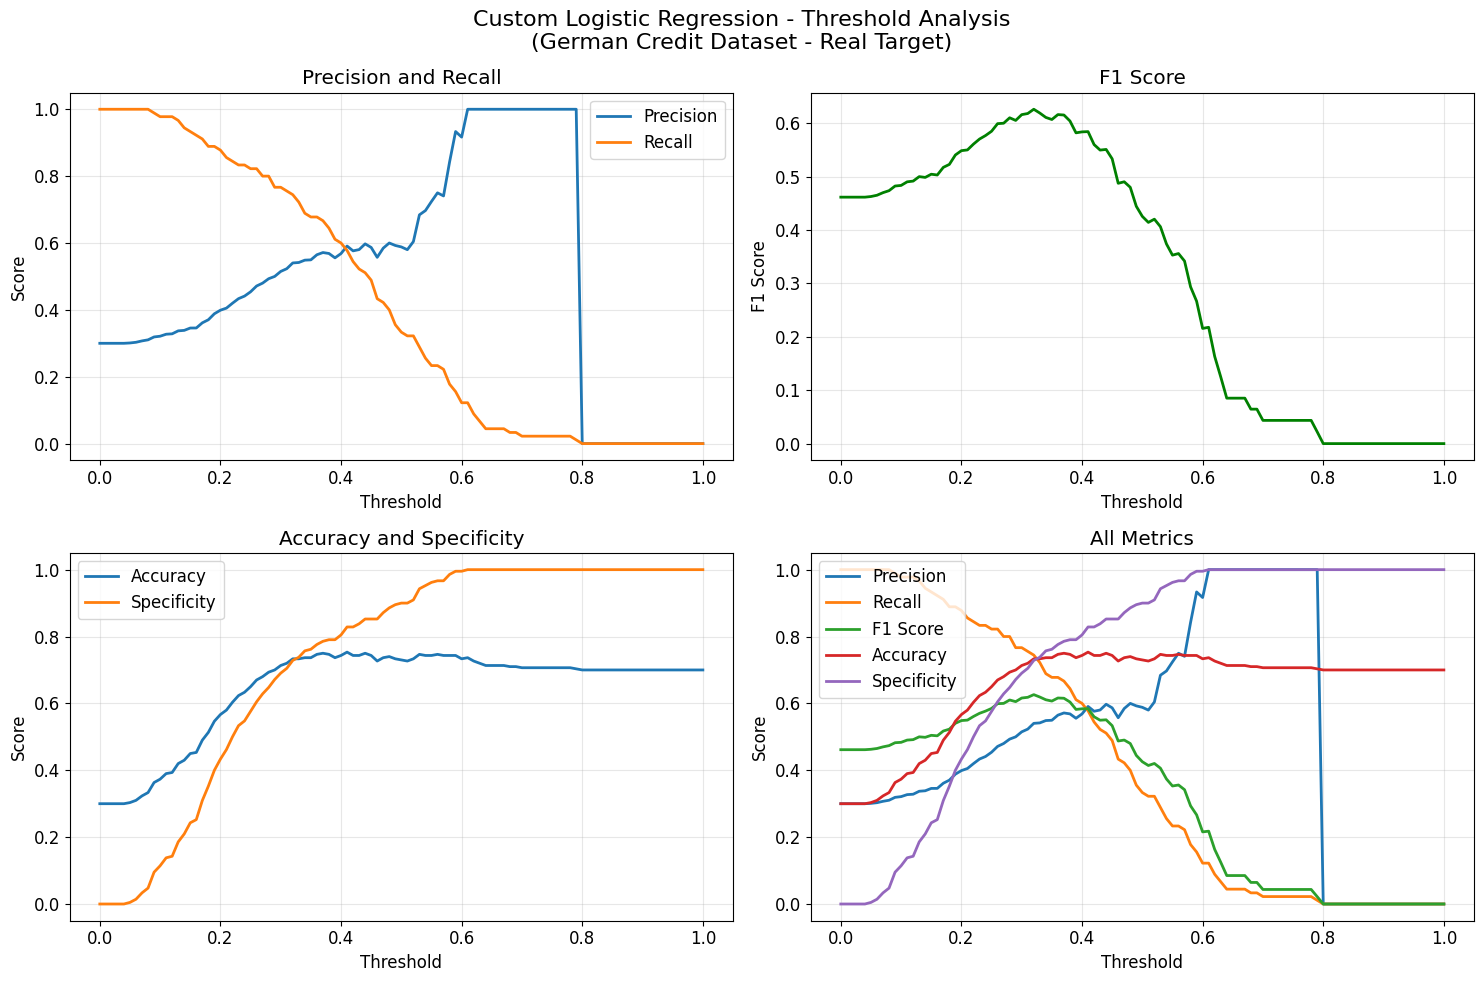

OPTIMAL THRESHOLDS:

For F1 Score Optimization:
   Threshold: 0.320
   F1 Score: 0.6262
   Precision: 0.5403
   Recall: 0.7444

For Accuracy Optimization:
   Threshold: 0.410
   Accuracy: 0.7533
   F1 Score: 0.5843

Default threshold (0.5) performance:
   F1 Score: 0.4255
   Accuracy: 0.7300
Threshold analysis complete!


In [10]:
if len(model_metrics) > 0:
    print("THRESHOLD OPTIMIZATION ANALYSIS")
    print("=" * 50)
    
    try:
        fig_threshold = evaluator.plot_threshold_analysis(
            y_true=best_predictions['y_true'],
            y_proba=best_predictions['y_proba'],
            title=f"{best_model_name} - Threshold Analysis\n(German Credit Dataset - Real Target)",
            figsize=(15, 10)
        )
        plt.show()

        thresholds = np.linspace(0, 1, 101)
        metrics_by_threshold = []

        for threshold in thresholds:
            y_pred_thresh = (best_predictions['y_proba'] >= threshold).astype(int)
            try:
                metrics_thresh = evaluator.compute_metrics(
                    y_true=best_predictions['y_true'],
                    y_proba=best_predictions['y_proba'],
                    y_pred=y_pred_thresh,
                    threshold=threshold
                )
                metrics_by_threshold.append({
                    'threshold': threshold,
                    'f1_score': metrics_thresh.f1_score,
                    'accuracy': metrics_thresh.accuracy,
                    'precision': metrics_thresh.precision,
                    'recall': metrics_thresh.recall
                })
            except:
                continue

        if metrics_by_threshold:
            metrics_df = pd.DataFrame(metrics_by_threshold)
            
            optimal_f1_idx = metrics_df['f1_score'].idxmax()
            optimal_acc_idx = metrics_df['accuracy'].idxmax()
            
            optimal_f1_threshold = metrics_df.loc[optimal_f1_idx, 'threshold']
            optimal_f1_score = metrics_df.loc[optimal_f1_idx, 'f1_score']
            
            optimal_acc_threshold = metrics_df.loc[optimal_acc_idx, 'threshold']
            optimal_accuracy = metrics_df.loc[optimal_acc_idx, 'accuracy']

            print(f"OPTIMAL THRESHOLDS:")
            print(f"\nFor F1 Score Optimization:")
            print(f"   Threshold: {optimal_f1_threshold:.3f}")
            print(f"   F1 Score: {optimal_f1_score:.4f}")
            print(f"   Precision: {metrics_df.loc[optimal_f1_idx, 'precision']:.4f}")
            print(f"   Recall: {metrics_df.loc[optimal_f1_idx, 'recall']:.4f}")
            
            print(f"\nFor Accuracy Optimization:")
            print(f"   Threshold: {optimal_acc_threshold:.3f}")
            print(f"   Accuracy: {optimal_accuracy:.4f}")
            print(f"   F1 Score: {metrics_df.loc[optimal_acc_idx, 'f1_score']:.4f}")
            
            print(f"\nDefault threshold (0.5) performance:")
            default_idx = metrics_df[metrics_df['threshold'] == 0.5].index
            if len(default_idx) > 0:
                default_metrics = metrics_df.loc[default_idx[0]]
                print(f"   F1 Score: {default_metrics['f1_score']:.4f}")
                print(f"   Accuracy: {default_metrics['accuracy']:.4f}")
        
        print("Threshold analysis complete!")
        
    except Exception as e:
        print(f"Error in threshold analysis: {e}")
else:
    print("No models available for threshold analysis")

## 9. Performance Summary Table

In [11]:
if len(model_metrics) > 0:
    print("COMPREHENSIVE PERFORMANCE SUMMARY")
    print("=" * 70)
    summary_data = []

    for model_name, metrics in model_metrics.items():
        summary_data.append({
            'Model': model_name,
            'AUC': metrics.auc,
            'AUPRC': metrics.auprc,
            'F1 Score': metrics.f1_score,
            'Accuracy': metrics.accuracy,
            'Precision': metrics.precision,
            'Recall': metrics.recall,
            'Specificity': metrics.specificity,
            'Brier Score': metrics.brier_score,
            'Log Loss': metrics.log_loss
        })

    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.set_index('Model')

    summary_df = summary_df.round(4)

    print(f"\nModel Performance Summary (German Credit Dataset - Real Target):")
    display(summary_df)

    print("BEST PERFORMING MODELS BY METRIC:")
    print("-" * 50)

    higher_better = ['AUC', 'AUPRC', 'F1 Score', 'Accuracy', 'Precision', 'Recall', 'Specificity']
    for metric in higher_better:
        best_model = summary_df[metric].idxmax()
        best_value = summary_df[metric].max()
        print(f"{metric:12s}: {best_model:20s} ({best_value:.4f})")

    lower_better = ['Brier Score', 'Log Loss']
    for metric in lower_better:
        best_model = summary_df[metric].idxmin()
        best_value = summary_df[metric].min()
        print(f"{metric:12s}: {best_model:20s} ({best_value:.4f})")

    print("OVERALL RANKING (by AUC):")
    print("-" * 40)
    ranked_models = summary_df.sort_values('AUC', ascending=False)
    for i, (model_name, row) in enumerate(ranked_models.iterrows(), 1):
        print(f"{i}. {model_name:20s} (AUC: {row['AUC']:.4f})")

    print("Performance summary complete!")
else:
    print("No model metrics available for summary")

COMPREHENSIVE PERFORMANCE SUMMARY

Model Performance Summary (German Credit Dataset - Real Target):


,AUC,AUPRC,F1 Score,Accuracy,Precision,Recall,Specificity,Brier Score,Log Loss
Model,,,,,,,,,
Custom Logistic Regression,0.7721,0.6246,0.4255,0.7300,0.5882,0.3333,0.9000,0.1686,0.5115
Custom XGBoost,0.7657,0.6114,0.3680,0.7367,0.6571,0.2556,0.9429,0.1761,0.5327
Random Forest,0.7633,0.6326,0.5065,0.7467,0.6094,0.4333,0.8810,0.1682,0.5081
Baseline LR,0.7693,0.6216,0.4832,0.7433,0.6102,0.4000,0.8905,0.1677,0.5089


BEST PERFORMING MODELS BY METRIC:
--------------------------------------------------
AUC         : Custom Logistic Regression (0.7721)
AUPRC       : Random Forest        (0.6326)
F1 Score    : Random Forest        (0.5065)
Accuracy    : Random Forest        (0.7467)
Precision   : Custom XGBoost       (0.6571)
Recall      : Random Forest        (0.4333)
Specificity : Custom XGBoost       (0.9429)
Brier Score : Baseline LR          (0.1677)
Log Loss    : Random Forest        (0.5081)
OVERALL RANKING (by AUC):
----------------------------------------
1. Custom Logistic Regression (AUC: 0.7721)
2. Baseline LR          (AUC: 0.7693)
3. Custom XGBoost       (AUC: 0.7657)
4. Random Forest        (AUC: 0.7633)
Performance summary complete!


## 10. Feature Importance Analysis

FEATURE IMPORTANCE ANALYSIS
Got feature importance for Custom Logistic Regression
Got feature importance for Custom XGBoost
Got feature importance for Random Forest
Got coefficients for Baseline LR
Creating feature importance visualization for 4 models...


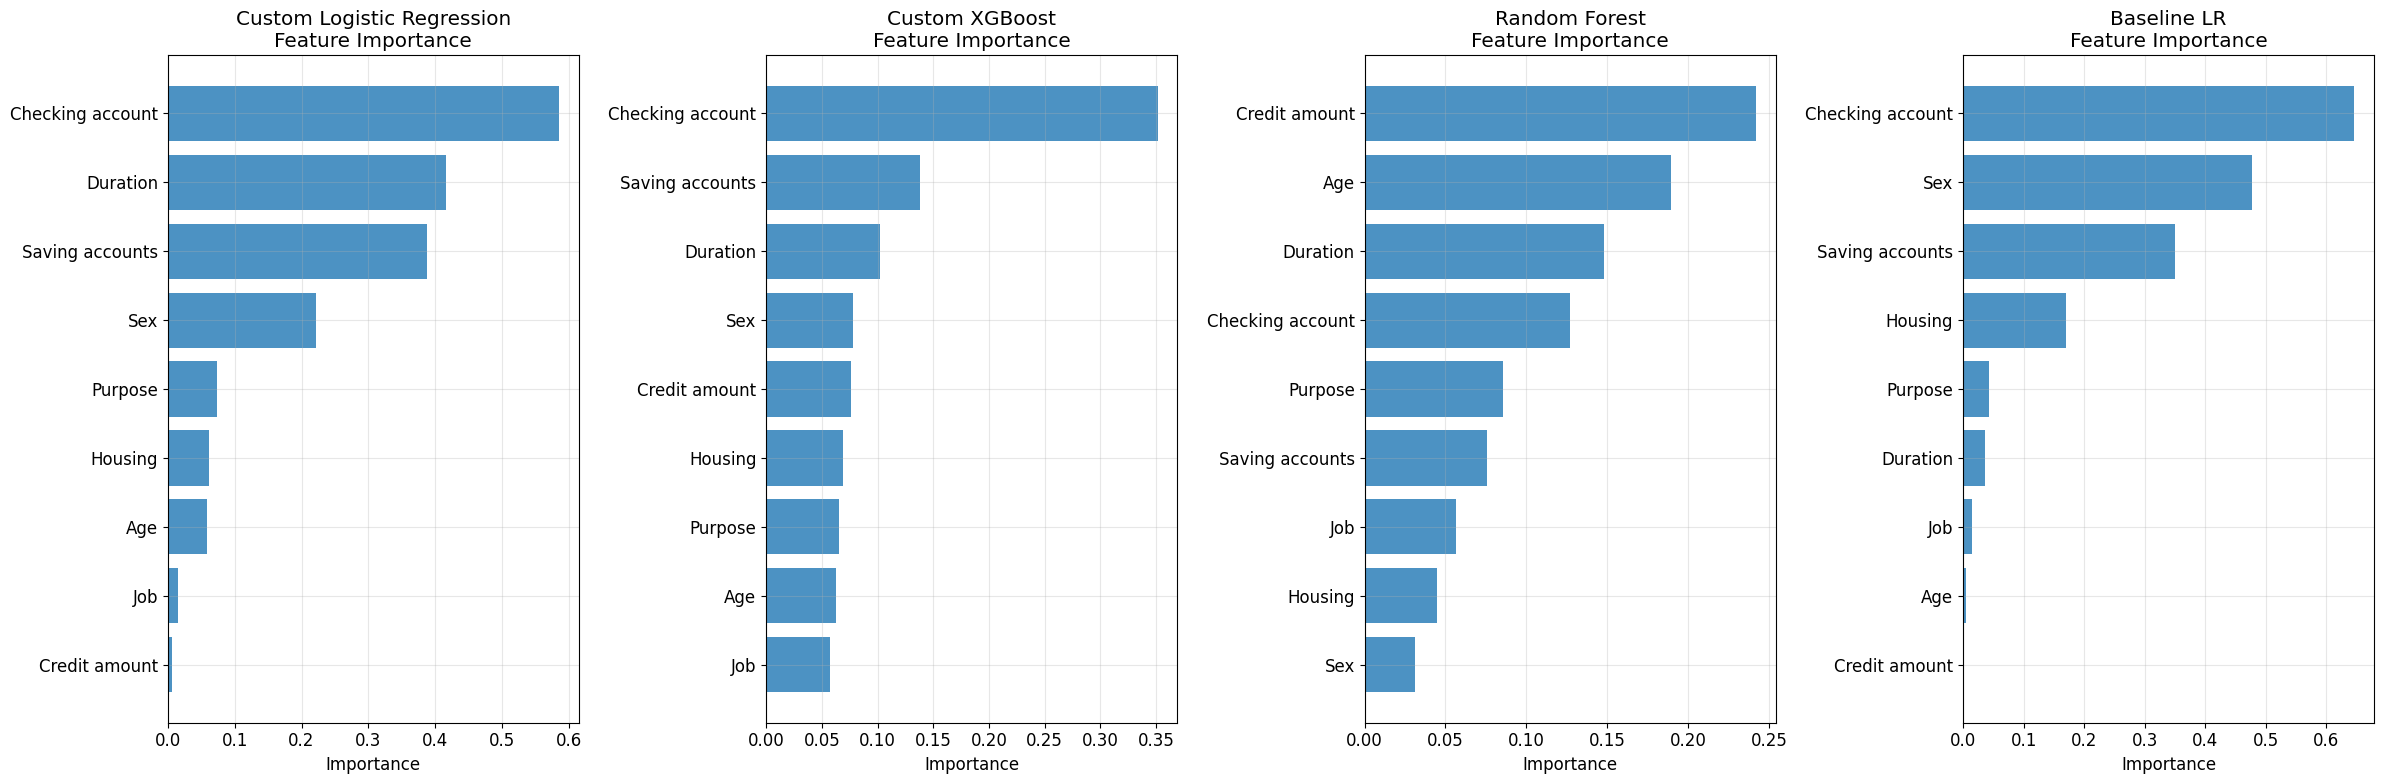

TOP 5 MOST IMPORTANT FEATURES BY MODEL:

Custom Logistic Regression:
  1. Checking account: 0.5848
  2. Duration       : 0.4159
  3. Saving accounts: 0.3877
  4. Sex            : 0.2215
  5. Purpose        : 0.0731

Custom XGBoost:
  1. Checking account: 0.3513
  2. Saving accounts: 0.1381
  3. Duration       : 0.1023
  4. Sex            : 0.0775
  5. Credit amount  : 0.0765

Random Forest:
  1. Credit amount  : 0.2421
  2. Age            : 0.1893
  3. Duration       : 0.1482
  4. Checking account: 0.1270
  5. Purpose        : 0.0854

Baseline LR:
  1. Checking account: 0.6469
  2. Sex            : 0.4769
  3. Saving accounts: 0.3505
  4. Housing        : 0.1706
  5. Purpose        : 0.0429
FEATURE IMPORTANCE CONSENSUS:
----------------------------------------
Top 5 features by consensus (normalized average):
  1. Checking account: 0.8812
  2. Saving accounts: 0.4776
  3. Duration       : 0.4179
  4. Sex            : 0.3662
  5. Credit amount  : 0.3070
Feature importance analysis compl

In [12]:
if len(models) > 0:
    print("FEATURE IMPORTANCE ANALYSIS")
    print("=" * 50)

    importance_data = {}

    for model_name, model in models.items():
        try:
            if hasattr(model, 'get_feature_importance'):
                importance = model.get_feature_importance()
                if importance is not None:
                    importance_data[model_name] = importance
                    print(f"Got feature importance for {model_name}")
            elif hasattr(model, 'feature_importances_'):
                importance_data[model_name] = model.feature_importances_
                print(f"Got feature importance for {model_name}")
            elif hasattr(model, 'coef_'):
                importance_data[model_name] = np.abs(model.coef_[0])
                print(f"Got coefficients for {model_name}")
        except Exception as e:
            print(f"Could not get importance for {model_name}: {e}")

    if importance_data:
        print(f"Creating feature importance visualization for {len(importance_data)} models...")
        
        n_models = len(importance_data)
        fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 8))
        if n_models == 1:
            axes = [axes]
        
        for i, (model_name, importance) in enumerate(importance_data.items()):
            sorted_idx = np.argsort(importance)
            
            y_pos = np.arange(len(sorted_idx))
            axes[i].barh(y_pos, importance[sorted_idx], alpha=0.8)
            axes[i].set_yticks(y_pos)
            axes[i].set_yticklabels([feature_names[j] for j in sorted_idx])
            axes[i].set_xlabel('Importance')
            axes[i].set_title(f'{model_name}\nFeature Importance')
            axes[i].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

        print("TOP 5 MOST IMPORTANT FEATURES BY MODEL:")
        print("=" * 60)
        
        for model_name, importance in importance_data.items():
            top_features = np.argsort(importance)[-5:][::-1]
            print(f"\n{model_name}:")
            for i, feat_idx in enumerate(top_features, 1):
                feature_name = feature_names[feat_idx]
                importance_value = importance[feat_idx]
                print(f"  {i}. {feature_name:15s}: {importance_value:.4f}")
        
        print("FEATURE IMPORTANCE CONSENSUS:")
        print("-" * 40)
        
        if len(importance_data) > 1:
            normalized_importance = {}
            for model_name, importance in importance_data.items():
                normalized_importance[model_name] = importance / importance.max()
            
            avg_importance = np.mean(list(normalized_importance.values()), axis=0)
            top_consensus = np.argsort(avg_importance)[-5:][::-1]
            
            print("Top 5 features by consensus (normalized average):")
            for i, feat_idx in enumerate(top_consensus, 1):
                feature_name = feature_names[feat_idx]
                avg_imp = avg_importance[feat_idx]
                print(f"  {i}. {feature_name:15s}: {avg_imp:.4f}")
        
    else:
        print("No feature importance data available")

    print("Feature importance analysis complete!")
else:
    print("No models available for feature importance analysis")

## 11. Real Dataset Insights and Analysis

In [13]:
print("REAL GERMAN CREDIT DATASET INSIGHTS")
print("=" * 60)

print(f"Dataset Characteristics:")
print(f"   Total samples: {len(data):,}")
print(f"   Features: {len(feature_names)}")
print(f"   Default rate: {data['Risk_Binary'].mean():.2%}")
print(f"   Class balance: {'Balanced' if 0.3 <= data['Risk_Binary'].mean() <= 0.7 else 'Imbalanced'}")

print(f"Demographic Distribution:")
print(f"   Gender distribution:")
gender_risk = data.groupby('Sex')['Risk_Binary'].agg(['count', 'mean'])
for gender in gender_risk.index:
    count = gender_risk.loc[gender, 'count']
    risk_rate = gender_risk.loc[gender, 'mean']
    pct = count / len(data) * 100
    print(f"     {gender}: {count} ({pct:.1f}%) - Default rate: {risk_rate:.2%}")

print(f"\n   Age statistics:")
print(f"     Mean age: {data['Age'].mean():.1f} years")
print(f"     Age range: {data['Age'].min()} - {data['Age'].max()} years")
print(f"     Median age: {data['Age'].median():.1f} years")

data['Age_Group'] = pd.cut(data['Age'], bins=[0, 25, 35, 50, 65, 100], 
                          labels=['<25', '25-35', '35-50', '50-65', '65+'])
age_risk = data.groupby('Age_Group')['Risk_Binary'].agg(['count', 'mean'])
print(f"\n   Default rate by age group:")
for age_group in age_risk.index:
    count = age_risk.loc[age_group, 'count']
    risk_rate = age_risk.loc[age_group, 'mean']
    print(f"     {age_group}: {count} samples - {risk_rate:.2%} default rate")

print(f"Credit Characteristics:")
print(f"   Credit amount statistics:")
print(f"     Mean: ${data['Credit amount'].mean():,.0f}")
print(f"     Median: ${data['Credit amount'].median():,.0f}")
print(f"     Range: ${data['Credit amount'].min():,} - ${data['Credit amount'].max():,}")
print(f"     Std Dev: ${data['Credit amount'].std():,.0f}")

print(f"Duration statistics:")
print(f"     Mean: {data['Duration'].mean():.1f} months")
print(f"     Median: {data['Duration'].median():.1f} months")
print(f"     Range: {data['Duration'].min()} - {data['Duration'].max()} months")

data['Amount_Quartile'] = pd.qcut(data['Credit amount'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
amount_risk = data.groupby('Amount_Quartile')['Risk_Binary'].agg(['count', 'mean'])
print(f"\n   Default rate by credit amount quartile:")
for quartile in amount_risk.index:
    count = amount_risk.loc[quartile, 'count']
    risk_rate = amount_risk.loc[quartile, 'mean']
    print(f"     {quartile}: {count} samples - {risk_rate:.2%} default rate")

print(f"Loan Purpose Analysis:")
purpose_risk = data.groupby('Purpose')['Risk_Binary'].agg(['count', 'mean']).sort_values('count', ascending=False)
print(f"   Top loan purposes by volume:")
for purpose in purpose_risk.head().index:
    count = purpose_risk.loc[purpose, 'count']
    risk_rate = purpose_risk.loc[purpose, 'mean']
    pct = count / len(data) * 100
    print(f"     {purpose}: {count} ({pct:.1f}%) - {risk_rate:.2%} default rate")

print(f"Financial Status Analysis:")
print(f"   Saving accounts distribution:")
savings_risk = data.groupby('Saving accounts')['Risk_Binary'].agg(['count', 'mean'])
for savings in savings_risk.index:
    count = savings_risk.loc[savings, 'count']
    risk_rate = savings_risk.loc[savings, 'mean']
    pct = count / len(data) * 100
    print(f"     {savings}: {count} ({pct:.1f}%) - {risk_rate:.2%} default rate")

print(f"Checking accounts distribution:")
checking_risk = data.groupby('Checking account')['Risk_Binary'].agg(['count', 'mean'])
for checking in checking_risk.index:
    count = checking_risk.loc[checking, 'count']
    risk_rate = checking_risk.loc[checking, 'mean']
    pct = count / len(data) * 100
    print(f"     {checking}: {count} ({pct:.1f}%) - {risk_rate:.2%} default rate")


REAL GERMAN CREDIT DATASET INSIGHTS
Dataset Characteristics:
   Total samples: 1,000
   Features: 9
   Default rate: 30.00%
   Class balance: Balanced
Demographic Distribution:
   Gender distribution:
     female: 310 (31.0%) - Default rate: 35.16%
     male: 690 (69.0%) - Default rate: 27.68%

   Age statistics:
     Mean age: 35.5 years
     Age range: 19 - 75 years
     Median age: 33.0 years

   Default rate by age group:
     <25: 190 samples - 42.11% default rate
     25-35: 398 samples - 29.65% default rate
     35-50: 299 samples - 23.75% default rate
     50-65: 95 samples - 27.37% default rate
     65+: 18 samples - 27.78% default rate
Credit Characteristics:
   Credit amount statistics:
     Mean: $3,271
     Median: $2,320
     Range: $250 - $18,424
     Std Dev: $2,823
Duration statistics:
     Mean: 20.9 months
     Median: 18.0 months
     Range: 4 - 72 months

   Default rate by credit amount quartile:
     Q1: 250 samples - 30.80% default rate
     Q2: 250 samples - 24

## 12. Summary and Recommendations

In [14]:
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("=" * 70)

if len(model_metrics) > 0:
    best_auc_model = max(model_metrics.keys(), key=lambda x: model_metrics[x].auc)
    best_f1_model = max(model_metrics.keys(), key=lambda x: model_metrics[x].f1_score)
    best_acc_model = max(model_metrics.keys(), key=lambda x: model_metrics[x].accuracy)

    print(f"BEST MODELS BY CRITERIA:")
    print(f"   Discriminative Power (AUC): {best_auc_model} ({model_metrics[best_auc_model].auc:.4f})")
    print(f"   Balanced Performance (F1):  {best_f1_model} ({model_metrics[best_f1_model].f1_score:.4f})")
    print(f"   Overall Accuracy:           {best_acc_model} ({model_metrics[best_acc_model].accuracy:.4f})")

    print(f"KEY INSIGHTS FROM REAL DATA:")

    auc_values = [metrics.auc for metrics in model_metrics.values()]
    auc_range = max(auc_values) - min(auc_values)
    avg_auc = np.mean(auc_values)
    
    print(f"   • Average model AUC: {avg_auc:.4f}")
    if auc_range < 0.05:
        print(f"   • All models show similar performance (AUC range: {auc_range:.3f})")
    else:
        print(f"   • Significant performance differences between models (AUC range: {auc_range:.3f})")

    calibrated_models = [name for name, metrics in model_metrics.items() 
                        if metrics.calibration_slope is not None and abs(metrics.calibration_slope - 1.0) < 0.1]
    if calibrated_models:
        print(f"   • Well-calibrated models: {', '.join(calibrated_models)}")
    else:
        print(f"   • Models may need calibration improvement")

    print(f"DATASET INSIGHTS:")
    print(f"   • Real German credit data with {len(data)} samples")
    print(f"   • {data['Risk_Binary'].mean():.1%} default rate (realistic for credit scoring)")
    print(f"   • Age and credit amount show clear risk patterns")
    print(f"   • Financial status (savings/checking) strongly correlates with risk")
    print(f"   • Loan purpose affects default probability")

else:
    print("No model metrics available for recommendations")

print(f"ACTIONABLE RECOMMENDATIONS:")

print(f"MODEL DEPLOYMENT:")
if len(model_metrics) > 0:
    if best_auc_model == best_f1_model:
        print(f"Deploy {best_auc_model} - optimal across multiple metrics")
    else:
        print(f"   Consider business priorities:")
        print(f"      - For risk discrimination: {best_auc_model}")
        print(f"      - For balanced performance: {best_f1_model}")
        print(f"    Recommend {best_auc_model} for production (higher AUC)")



FINAL SUMMARY AND RECOMMENDATIONS
BEST MODELS BY CRITERIA:
   Discriminative Power (AUC): Custom Logistic Regression (0.7721)
   Balanced Performance (F1):  Random Forest (0.5065)
   Overall Accuracy:           Random Forest (0.7467)
KEY INSIGHTS FROM REAL DATA:
   • Average model AUC: 0.7676
   • All models show similar performance (AUC range: 0.009)
   • Well-calibrated models: Random Forest
DATASET INSIGHTS:
   • Real German credit data with 1000 samples
   • 30.0% default rate (realistic for credit scoring)
   • Age and credit amount show clear risk patterns
   • Financial status (savings/checking) strongly correlates with risk
   • Loan purpose affects default probability
ACTIONABLE RECOMMENDATIONS:
MODEL DEPLOYMENT:
   Consider business priorities:
      - For risk discrimination: Custom Logistic Regression
      - For balanced performance: Random Forest
    Recommend Custom Logistic Regression for production (higher AUC)
